In [11]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

incorrect startxref pointer(1)
parsing for Object Streams


Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_tool_use",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [7]:
from langchain_groq import ChatGroq


llm = ChatGroq(model="openai/gpt-oss-20b")        # route_question and generate

agent_llm = ChatGroq(model="openai/gpt-oss-20b")   # agent node; tools bound later

In [8]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

In [9]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [10]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [12]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [13]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [14]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [15]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [16]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [17]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [18]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [20]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [21]:
graph = graph_builder.compile()

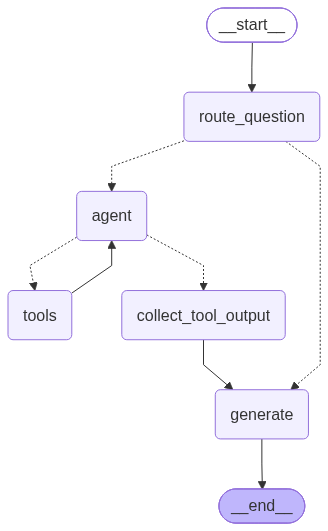

In [22]:
graph

In [23]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [24]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval : True
retrieved_docs  : 10 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
**Impact of EV adoption on oil demand – key take‑aways from the report**

| Time horizon | Expected effect | Key points |
|--------------|-----------------|------------|
| **Near‑term (now – 2030)** | *Modest but meaningful reduction* | • EV penetration will shave a noticeable amount of oil demand growth, but not enough to eliminate future price shocks. <br>• The displacement mainly cuts gasoline use (the fuel for passenger cars); diesel demand – which powers heavy trucks, buses, etc. – is harder to replace. <br>• By flattening or even reversing the demand‑growth curve, EVs increase the chance that global spare capacity stays above the “insurance” threshold (≈2–3 million b/d), giving a small buffer against supply shocks. |
| **Mid‑term (2030 – 2050)** 

In [25]:
print(result_vs["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 3
Executive Summary
 The global transition toward electric vehicles (EVs) has emerged as one of the most
consequential structural shifts in energy markets since the oil crises of the 1970s.
Transportation accounts for roughly 57 percent of global oil demand, and road transport alone
represents the single largest sub-segment. As EV adoption accelerates — driven by falling
battery costs, tightening emissions regulations, and expanding charging infrastructure — a
fundamental question has risen to the top of the energy policy agenda: will the mass
displacement of internal combustion engine (ICE) vehicles materially reduce oil price volatility
and cushion economies against future oil price shocks? This report examines that question

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 7
consumption, th

In [26]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [27]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval : True
retrieved_docs  : 3 docs
context preview : 

## Web Search Results

1. What is the current temperature in New Delhi today - 16 September 2026?

The current tempera...

Generation:
The most recent update in the context shows that the current temperature in New Delhi is **32 °C** (feels like 34 °C).


In [28]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [29]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval : True
retrieved_docs  : 19 docs
context preview : 

## Vector Store Results

longer in developing markets — complete fleet electrification cannot occur in less than two t...

Generation:
**EV‑report projections for 2030 oil demand**

| Scenario | EV fleet by 2030 | Oil displaced per day | Effect on global demand (≈ 100‑105 mb/d) |
|----------|------------------|-----------------------|----------------------------------------|
| **High‑adoption (IEA Net‑Zero 2050 pathway)** | ~300 million passenger/light‑commercial EVs | ~4.6 million barrels per day (b/d) | Roughly a 4‑5 % cut in the 100‑105 mb/d global demand – a *modest* but tangible reduction. |
| **Moderate‑adoption (OPEC “central” outlook)** | ~200‑250 million EVs | 2–3 million b/d | About a 2‑3 % cut – still noticeable but far less transformative. |

**Key take‑aways**

* The EV report stresses that fleet inertia means the *first wave* of EVs will only shave a few million barrels a day o

In [30]:
print(result_both["context"])



## Vector Store Results

longer in developing markets — complete fleet electrification cannot occur in less than two to
three decades even under the most aggressive adoption scenarios. This fleet inertia is the
primary reason why even optimistic EV projections show only modest oil demand
displacement through 2030, with the major effects occurring in the 2030–2050 window.
 Under a high-adoption scenario broadly consistent with the IEA's Net Zero by 2050
pathway, the global EV stock reaches approximately 300 million vehicles by 2030 and 900
million by 2035. Each EV on the road displaces roughly 560 liters of gasoline per year on
average, equivalent to approximately 1 barrel of oil per month per vehicle. A fleet of 300
million EVs would therefore displace approximately 4.6 million barrels of oil per day by 2030
— a meaningful but not transformative reduction against a global demand base of 100 to 105

Energy Agency, and McKinsey collectively project that EVs will account for between 40 

In [31]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [32]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval : False
retrieved_docs  : 0 docs
context preview : (none)

Generation:
**Kinetic energy** and **potential energy** are the two most common forms of mechanical energy that a system can possess. They differ in *how* the energy is stored and *what it depends on*.

| Feature | Kinetic Energy (KE) | Potential Energy (PE) |
|---------|---------------------|-----------------------|
| **What it represents** | Energy of motion | Energy stored because of position, configuration, or state |
| **Depends on** | Mass and velocity of the object | Mass and height (for gravity), displacement in a spring, charge distribution, etc. |
| **Typical formula** | \( KE = \tfrac12 m v^2 \) | \( PE = mgh \) (gravity), \( \tfrac12 k x^2 \) (spring), \( \tfrac12 C V^2 \) (capacitor), etc. |
| **Can be negative** | No (always ≥ 0) | Yes, if a reference point is chosen such that PE can be negative (e.g., gravitational PE below the chosen zero). |
| **Direction** | Require

In [33]:
result_both["messages"][0].tool_calls

[{'name': 'vector_store_search',
  'args': {'k': 5,
   'query': '2030 oil demand projection EV report 2030 oil demand'},
  'id': 'fc_7796f5ce-8468-465e-9902-ed6d7c9190be',
  'type': 'tool_call'}]